$\newcommand\indi[1]{{\mathbf 1}_{\displaystyle #1}}$
$\newcommand\inde[1]{{\mathbf 1}_{\displaystyle\left\{ #1 \right\}}}$
$\newcommand{\ind}{\inde}$
$\newcommand\E{{\mathbf E}}$
$\newcommand\Cov{{\mathrm Cov}}$
$\newcommand\Var{{\mathrm Var}}$


# 1. Introduction

On considere $d$ actifs dont les rendements sont donnés pas
$(R_1,\ldots,R_d)$.  L'hypothèse de rendement signifie que si on
détient à l'instant $0$ une quantité d'actif $i$ de valeur $V$, la
valeur de cette même quantité d'actif à l'instant $T$ (égal à $T=1$ an
par exemple) sera donnée par $V(1+R_i)$.

On suppose de plus que ces rendements ont des caractéristiques de
moyenne et de variance connues. On note $\mu$ le vecteur des espérances
$\mu_i=\E(R_i)$ et $\Gamma$ la matrice de variance covariance, où
$\Gamma_{ij}=\Cov(R_i,R_j)$. On note $\sigma_i^2=\Var(R_i)=\Gamma_{ii}$.


## 1.1. Le cas à deux actifs risqués

On suppose que $d=2$, que $\mu_1=5\%$ et $\mu_2=15\%$, que
$\sigma_1=10\%$ et $\sigma_2=30\%$ et $\rho$ étant un paramètre réel,
$\Gamma$ est donnée par
$$
   \Gamma=\left(\begin{array}{cc}
      \sigma_1^2 & \rho \sigma_1 \sigma_2\\
      \rho \sigma_1 \sigma_2 &  \sigma_2^2 
   \end{array}\right).
$$

#### Question 1.

 Que représente $\rho$ ? A quelle condition sur $\rho$ la matrice
  $\Gamma$ est la matrice de covariance d'un vecteur aléatoire ? Dans
  les simulations, on prendra $\rho=0$.

  On constitue un portefeuille de valeur initiale $X_0=1$  constitué
  d'une quantité $x_1$ d'actif $1$ et $x_2$ d'actif $2$ avec
  $x_1\geq 0$, $x_2\geq 0$ et $X_0=x_1+x_2=1$ (i.e. on répartit $1$E
  entre les deux actifs risqués). On note $X_T$ la valeur de ce
  portefeuille en $T$.

  Vérifier que si le gain $G_T$ est défini par $G_T=X_T-X_0$,
  $$\E(G_T)=\mu_1 x_1 + \mu_2 x_2=\mu_2 + x_1(\mu_1-\mu_2)$$ et
  $$\Var(G_T)=x.\Gamma x=\sigma_1^2 x_1^2 + \sigma_2^2 (1-x_1)^2 + 2
  \rho \sigma_1\sigma_2 x_1 (1-x_1).$$

#### Question 2.

 Tracer les caractéristiques des actifs de base dans le plan (moyenne,écart type).

[[0.01 0.  ]
 [0.   0.09]]


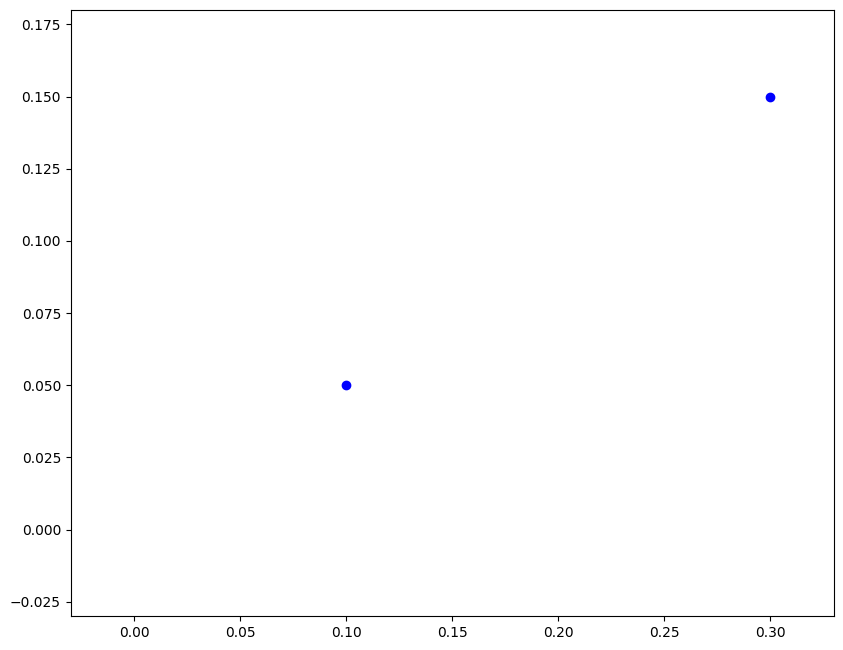

In [1]:
import numpy as np;
import math;
import random;
import matplotlib.pyplot as plt;


# On définit les caracteristiques des actifs
d=2;
mu=[0.05,0.15];
# Matrice de covariance: des 1 sur la diagonale, des rho ailleurs
rho=0.;
covariance=rho*np.ones([d,d])+(1-rho)*np.eye(d);
sigma=[0.10,0.30];
Gamma = np.dot(np.dot(np.diag(sigma),covariance),np.diag(sigma));#produit matriciel
print(Gamma)
# Les caractéristiques des actifs de base
moyenne_actif=mu;
std_actif=sigma;

# plot ###################################################################
max_sigma=max(std_actif)
max_esp=max(moyenne_actif)
marge=0.03
un_inche_en_cm=2.54; # 1 inche = 2.54 cm

taille_h_cm=25;
taille_v_cm=20;

def plot1():
    # On crée un figure dont on fixe la taille et dont on définit les axes
    fig = plt.gcf();
    fig.set_size_inches(taille_h_cm/un_inche_en_cm,taille_v_cm/un_inche_en_cm);
    plt.axis([-marge, max_sigma+marge, -marge, max_esp+marge]);
    # On trace les points représentant les 2 actifs.
    plt.plot(sigma,mu, 'bo');

plot1();


#### Question 3.

Tracer la courbe $x_1\in [0,1] \to (\E(G_T),\sqrt{\Var(G_T)})$.
  
  Vérifier que l'on peut construire un portefeuille de même variance
  que l'actif $1$ mais dont l'espérance du rendement est supérieure à
  celle de cet actif. Est il rationnel d'investir dans l'actif $1$,
  si l'on cherche à minimiser son risque ?

  Quel sont les portefeuilles dans lesquels il paraît rationnel d'investir ?


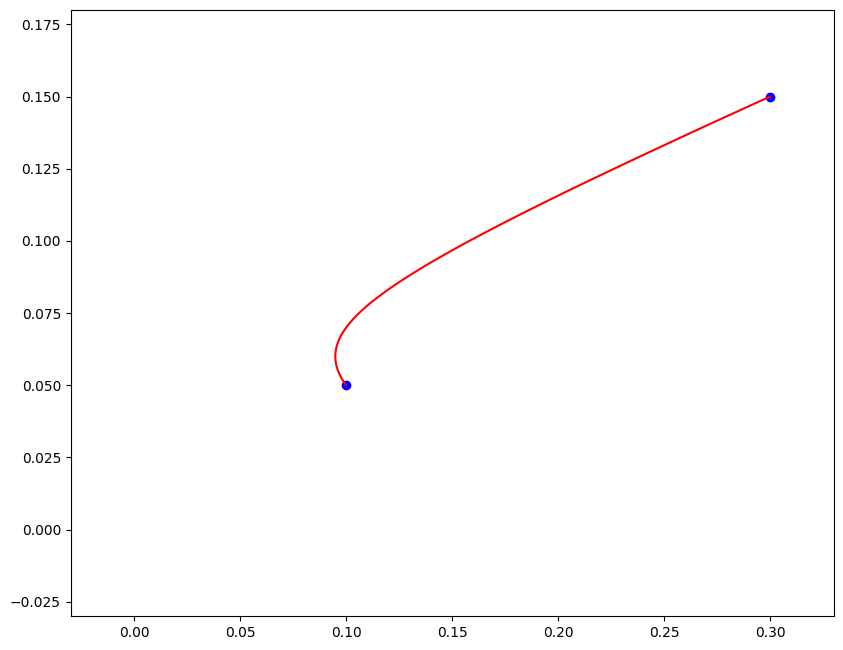

In [2]:
N=100;
moyenne_x=np.zeros(N);
std_x=np.zeros(N);
i=0;
for x_1 in np.linspace(0,1,N):
    current_x = [x_1,1-x_1];
    moyenne_x[i] = np.dot(mu,current_x);
    std_x[i]=np.sqrt(np.dot(current_x,np.dot(Gamma,current_x)));
    i=i+1;
    
# plot ###################################################################
def plot2():
    plot1();# le plot précédent
    plt.plot(std_x,moyenne_x, 'r-');
    
plot2();


4. Vérifier que l'on peut construire un portefeuille de variance
  minimum (et inférieure à celle de l'actif de variance
  minimum). C'est un exemple de l'__effet de diversification__ dans
  la théorie des portefeuille.

0.8989898989898991


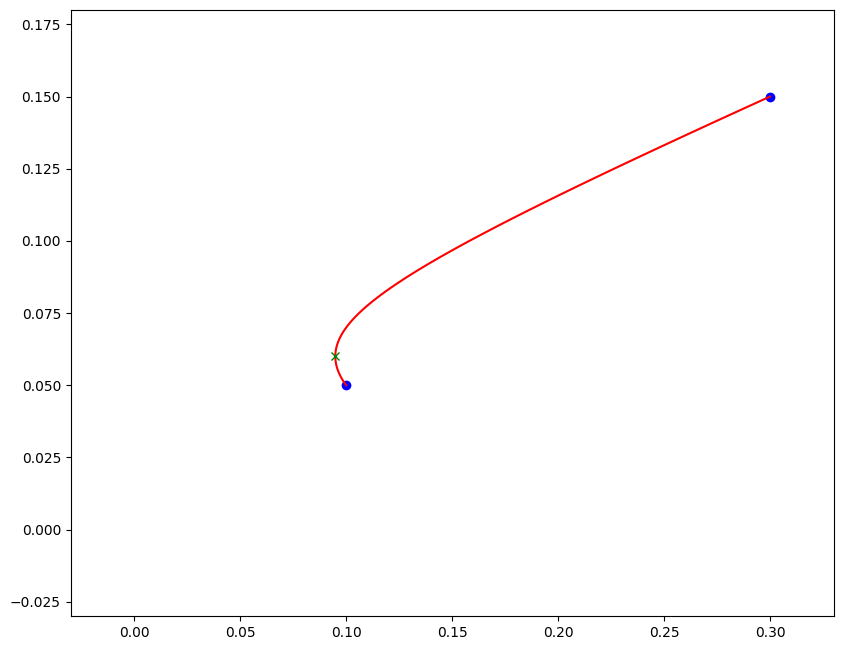

In [3]:
# plot ###################################################################
def plot3():
    plot2();# le plot précédent
    imin=std_x.argmin();
    plt.plot(std_x[imin],moyenne_x[imin], 'gx');

    
plot3();

imin=std_x.argmin()
print((np.linspace(0,1,N))[imin])

5. Nous relaxons la condition $x_1\geq 0$, $x_2\geq 0$ tout en
  continuant à imposer $x_1+x_2=1$ (la valeur totale de notre
  investissement initial reste égale à $1$). Nous allons faire varier
  $x_1$ entre $-10$ et $0$ (lorsque $x_1$ est négatif, on emprunte une
  quantité $|x_1|$ d'actif $1$, mais la valeur totale du portefeuille
  doit toujours rester égale à $1$).

 Tracer la courbe $x_1\in [-5,0] \to
 (\E(G_T),\sqrt{\Var(G_T)})$. Vérifier que, si l'on accepte une
 variance grande, on peut constituer des portefeuilles d'espérance
 aussi grande que souhaitée (cet effet porte le nom d'__effet de
   levier__ ou leverage effect). On comprend qu'il ne faille pas en
 abuser !

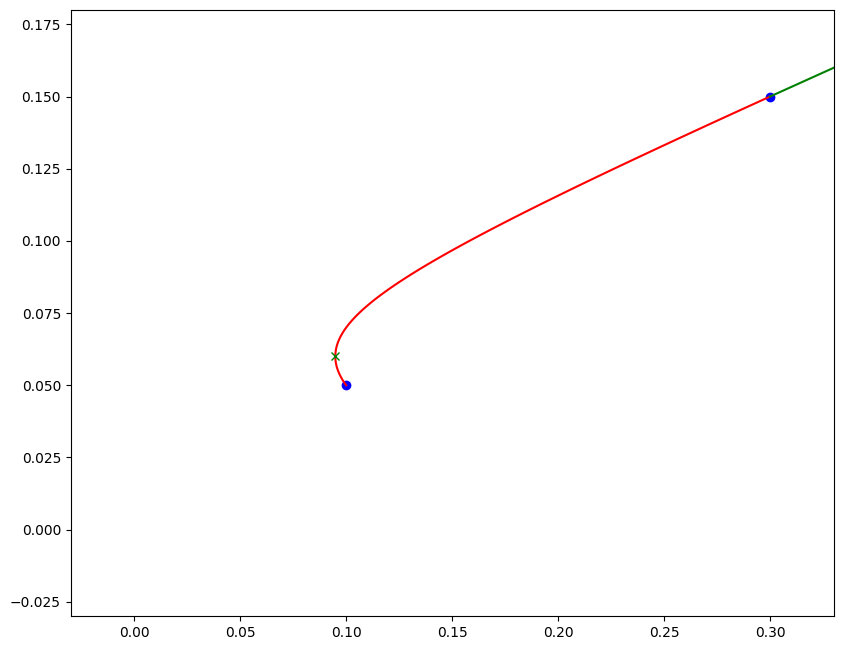

In [4]:
# On autorise l'emprunt de l'actif 1
N=1000;
moyenne2_x=np.zeros(N);
std2_x=np.zeros(N);
for i in range(0,N):
  # quantité négative = emprunt de l'actif 1
  #QUESTION: x_1= # QUE VAUT x_1;  
  x_1= - 5*i/(N-1);
  x_2=1-x_1;
  x=[x_1,x_2];
  moyenne2_x[i]=np.dot(mu,x);
  std2_x[i]=np.sqrt(np.dot(x,np.dot(Gamma,x)));

# plot ###################################################################
def plot4():
    plot3();# le plot précédent
    plt.plot(std2_x, moyenne2_x,'g-');
    
plot4();

6. Tracer la courbe $x_2\in [-5,0] \to
 (\E(G_T),\sqrt{\Var(G_T)})$.
 Vérifier que lorsque l'on emprunte
 l'actif $2$ ($x_2$ négatif), l'on fait décroître l'espérance en
 augmentant la variance (ce qui est loin d'être optimal!).

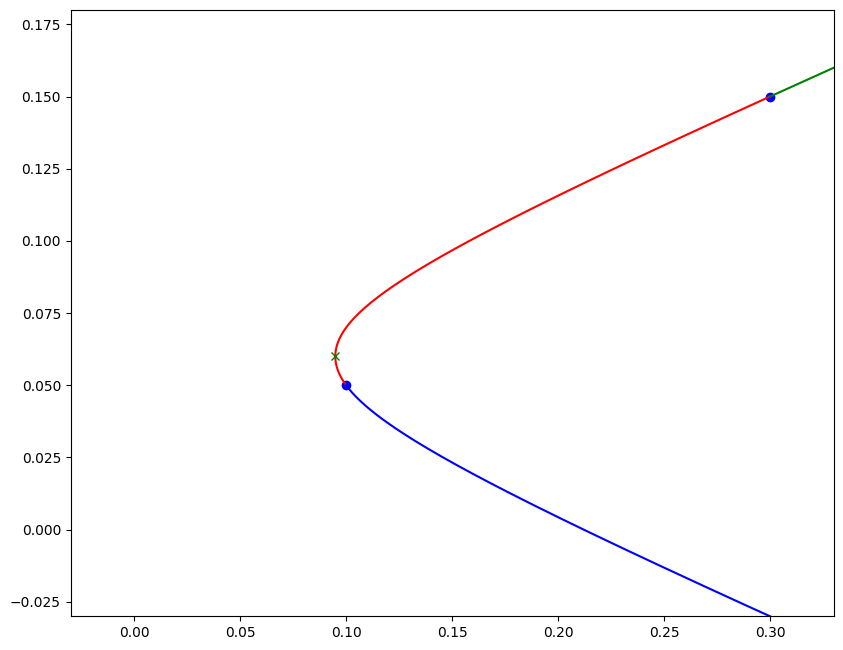

In [5]:
# Que se passe t'il lorsque l'on emprunte l'actif 2 ?
N=1000;
moyenne3_x=np.zeros(N);
std3_x=np.zeros(N);
for i in range(0,N):
  #quantité négative = emprunt de l'actif 2
  #QUESTION: x_2 = # QUE VAUT x_2;
  x_2=-5*i/N;
  x_1=1-x_2;
  x=[x_1,x_2];
  moyenne3_x[i]=np.dot(mu,x)
  std3_x[i]=math.sqrt(np.dot(x,np.dot(Gamma,x)));

# plot ###################################################################
def plot5():
    plot4();# le plot précédent
    plt.plot(std3_x, moyenne3_x,'b-');
    
plot5();

 Nous allons introduire un nouvel actif, l'actif sans risque, qui
  comme son nom le suggère aura un rendement de variance nulle (ce qui
  implique que ce rendement n'est pas aléatoire). On supposera que ce
  rendement déterministe est inférieur à tous les rendements moyens
  des actifs risqués (pourquoi est-ce une hypothèse raisonnable?). On
  prendra, ici, ce rendement égal à $0$.

  On constitue des portefeuilles avec les 3 actifs (1 non risqué, 2
  risqués) en tirant au hasard des coefficients $(x_1,x_2,x_3)$ dans
  le simplexe $\left\{0\leq x_i \leq 1,i=1,2,3 \mbox{ et }
    x_1+x_2+x_3=1\right\}$. La fonction $simplexe(d)$ figurant dans
  "utils.sci" pour $d=3$ fait ce travail.

 8. Matérialiser, en tirant un grand nombre points au hasard, la nouvelle frontière
  efficiente. Vérifier que :
  
    -la nouvelle frontière efficiente étend l'ancienne par de
    nouveaux points "non dominés" entre l'actif sans risque et un
    portefeuille tangent à l'ancienne frontière $P$.
    
    -la variance reste bornée par la variance la plus grande
    (tant que l'on ne fait pas d'emprunt).

In [6]:
#print(d)
#x=[6,5,9]
#x=np.sort(x)[::-1]
#print(x)
#[9 6 5]


#t=np.random.rand(d-1)
#print(t)

print(list(range(d-1,-1,-1)))

def simplexe(d):
# tirages de d nombre positifs
# de somme egale 1
  t=np.random.rand(d-1);
  t=np.sort(t)[::-1];
  t=np.append(1,t);
  t=np.append(t,0);
  s=np.zeros(d)
  for i in range(d-1,-1,-1):
      s[i]=t[i]-t[i+1]; # terme d'une somme telescopique
  return s;

s=simplexe(4)
print(s)


[1, 0]
[0.40706499 0.34625169 0.22416291 0.02252041]


[[0.   0.   0.  ]
 [0.   0.01 0.  ]
 [0.   0.   0.09]]


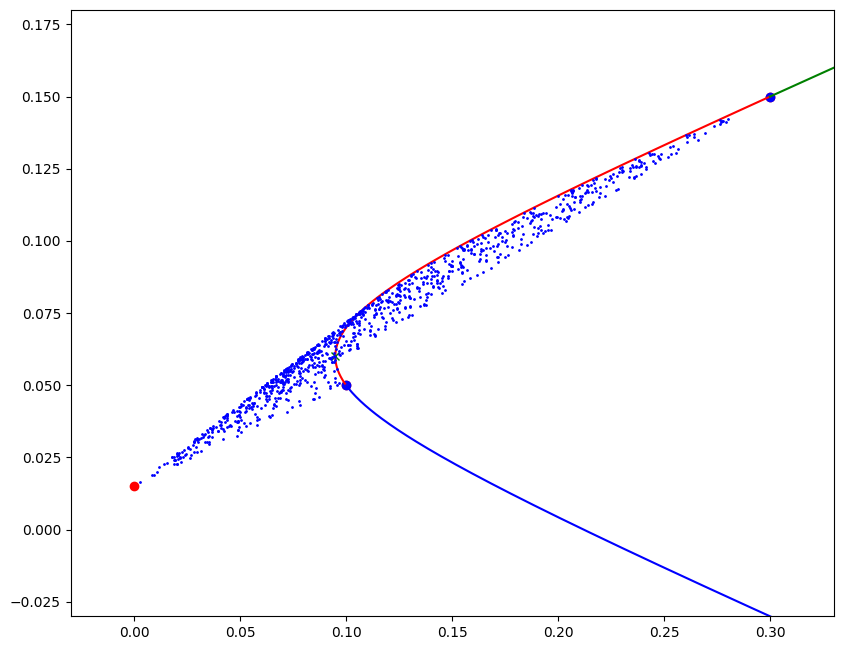

In [7]:
# On rajoute un actif sans risque de moyenne nulle
r0=0.015;
mu_d=np.append(r0,mu);
sigma_d=np.append(0,sigma);

rho=0.0;# -0.5
covariance=rho*np.ones([d,d])+(1-rho)*np.eye(d)
Gamma = np.matmul(np.matmul(np.diag(sigma),covariance), np.diag(sigma))
# comme ce rendement est suppose deterministe, la matrice de  
# variance covariance se complete par une ligne et une colonne de 0
#QUESTION: Gamma= # QUE VAUT GAMMA DANS CE CAS
#REPONSE: 
Gamma_d=np.vstack([np.zeros(d),Gamma])
Gamma_d=np.c_[np.zeros(d+1),Gamma_d]
print(Gamma_d)

moyenne_actif=mu_d;
std_actif=np.sqrt(np.diag(Gamma_d));

# On materialise les 3 actifs de base
plt.plot(std_actif, moyenne_actif, 'ro');

# On considère des portefeuilles *avec l'actif sans risque*
# mais *sans emprunt*. On les tire au hasard dans le simplexe
# de dimension 3
N=1000; #N stratégies 
moyenne_d_x=np.zeros(N);
std_d_x=np.zeros(N);
for i in range(0,N):
  x=simplexe(d+1);# tirage au hasard dans le simplexe 
  moyenne_d_x[i] = np.dot(mu_d,x);
  std_d_x[i]=math.sqrt(np.dot(x,np.matmul(Gamma_d,x)));

# plot ###################################################################
def plot6():
    plot5();# le plot précédent
    plt.plot(std_d_x, moyenne_d_x,'b.',markersize=2);

plot6();

# Commentaire

On obtient de nouveaux points "non
  dominés" entre l'actif sans risque et un portefeuille tangent.  La
  variance reste bornée par la variance de l'actifs de plus grande
  variance tant que l'on n'emprunte pas.

On va identifier un portefeuille particulier $P$, le "portefeuille de
  marché".  $P$ est le portefeuille correspondant au point de
  tangence de la droite passant par l'actif sans risque et de
  l'ensemble de tous les portefeuilles a coefficients positifs de la
  question précédente.

  Le point $P$ est caractérisé par le fait qu'il maximise la pente des
  droites reliant le point $(\sigma_0=0, r_0=0)$ et les points
  correspondants à des portefeuilles $y$ ne faisant pas intervenir
  d'actif sans risque.



  Question 9. Toujours en procédant par simulation dans le simplexe, calculer $P$
  (en fait une approximation de $P$).

  Vérifier que le portefeuille $P$ fait intervenir les $2$ actifs
  risqués.

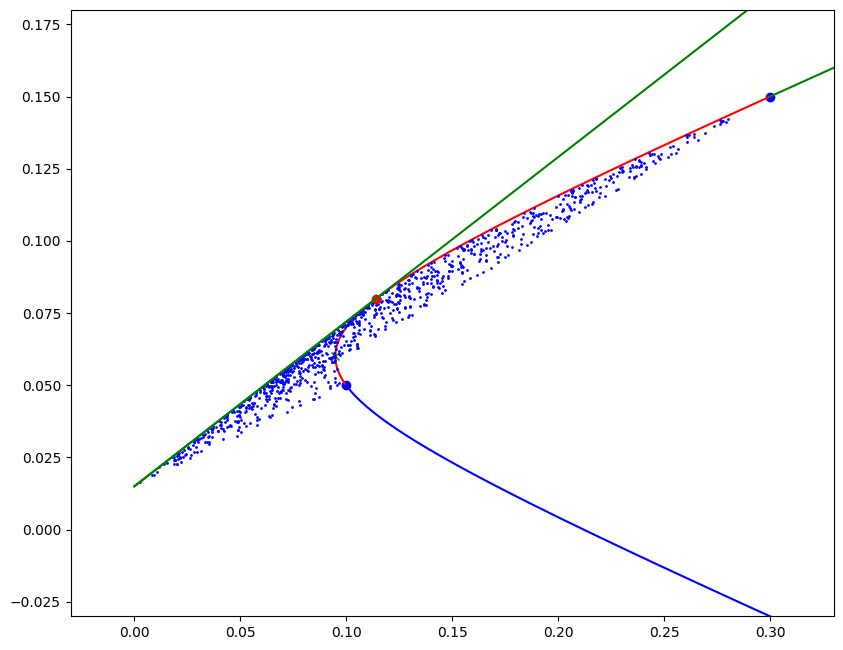

In [8]:
# On genere des portefeuilles sans actifs sans risque
N=1000;
r0=mu_d[0];
sigma0=sigma_d[0];# sigma0 = Gamma_d(1,1) = 0

moyenne_y=np.zeros(N);
std_y=np.zeros(N);
max_pente=0;
for i in range(1,N):
  # cas d=2
  y = np.array([0,i/N,1-i/N]); # on  rajoute O en actif sans risque
  # on calcule les moyennes et variances des portefeuilles y
  moyenne_y[i]=np.dot(mu_d,y);
  std_y[i]=math.sqrt(np.dot(y,np.matmul(Gamma_d,y)))  
  pente=(moyenne_y[i] - r0) / (std_y[i] - sigma0);# calcul de la pente
  max_pente=max(pente,max_pente);
  if max_pente==pente:
        imax=i

# Le point P maximise la pente de la droite entre (sigma0=0, x_0=r0) 
# et les portefeuilles y (sans actif sans risque)
x_P=moyenne_y[imax];
sigma_P=std_y[imax];

# plot ###################################################################
def plot7():
    plot6();# le plot précédent

    # Tracé du point P
    plt.plot(sigma_P, x_P, 'ro')

    # Tracé du segment "Actif sans risque -> P"
    plt.plot(np.array([sigma0,sigma_P]),np.array([r0,x_P]), 'g-');

    # Tracé de la droite "actif sans risque -> P" au dela de P
    lambd=(x_P-r0)/(sigma_P-sigma0)# pente de la droite
    sigma_infinity=2.0# arbitraire mais "grand"
    x_infinity=r0+lambd*(sigma_infinity-sigma0);
    plt.plot(np.array([sigma0,sigma_infinity]),np.array([r0,x_infinity]), 'g-');

plot7();

### Question 10.

On autorise la détention d'une quantité de signe arbitraire
  d'actif sans risque (cela correspond soit à un emprunt, soit à un
  placement). Pour cela on vous suggère de tirer la quantité d'actif
  sans risque $x_0$ entre $[-4,1]$ (on peut emprunter jusqu'à $4$ fois
  ce que l'on possède). Puis on tire, les quantités d'actifs
  risqués uniformément sur le simplexe $\{x_1+x_2=1-x_0\}$.
  
  Tirer un grand nombre de portefeuille, calculer leurs moyennes et écarts-type,
  les tracer sur la figure.

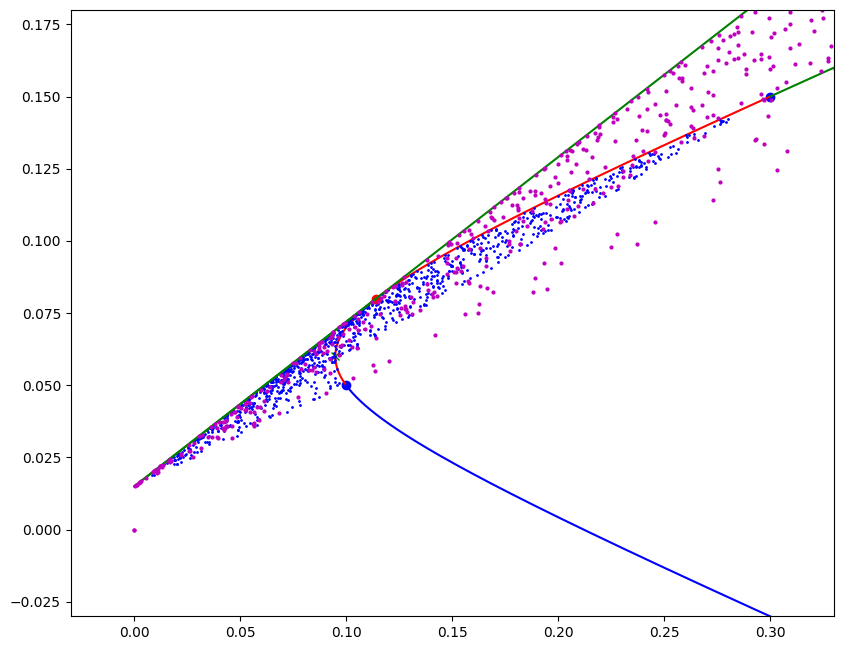

In [9]:
# L'emprunt en actif sans risque est autorisé
N=1000; #nombre de stratégies
moyenne_x_d=np.zeros(N+1);
std_x_d=np.zeros(N+1);
for i in range(1,N):
  # On génère des portefeuilles dont la quantité 
  # d'actif sans risque est uniforme sur [-4,1]
  x_0 = -4+ 5* np.random.rand(1);
  s=simplexe(d);
    # tirage uniforme dans le simplexe de dim |$d$|.
    # On veut génèrer un portefeuille avec x_0 actifs sans risque
    # et de valeur totale |$x_0 + \sum_{i=1,\ldots,d} x_i = 1$|.
  x=np.append(x_0,(1-x_0)*s);

    # |$x_0 + (1- x_0) \sum_{i=1,\ldots,d} s_i = 1$|  
  #print(x)
  moyenne_x_d[i]= np.dot(mu_d,x);
  std_x_d[i]=math.sqrt(np.dot(x, np.matmul(Gamma_d,x)));

# plot ###################################################################
def plot8():
    plot7();# le plot précédent

    # Tracé des points tirés au hazard    
    plt.plot(std_x_d,moyenne_x_d,'mo',markersize=2);

plot8();

  Vérifier que:
  1. l'on obtient de nouveaux points "non dominés" au delà du
    portefeuille tangent.
  2. le rendement (mais aussi la variance) peut devenir aussi
    grand que souhaité: __effet de levier__.
  3. un emprunt permet de construire des portefeuilles dont la
    moyenne des rendements est plus élevée à variance égale:
      __emprunter permet d'augmenter le rendement__.
  4. l'emprunt permet de construire des portefeuilles de même
    moyenne mais de variance inférieure: __emprunter permet de
      réduire le risque__.  Il existe en particulier un portefeuille
    dont la variance est égale à celle de l'actif 2 (l'actif de
    rendement maximum) mais de rendement supérieur.
  5. le seul point de la "frontière sans emprunt" qui n'est pas
    dominé par un point de la "frontière avec emprunt" est le point
    $P$~: si l'on ne souhaite pas emprunter, le seul point
      rationnel est $P$.
  6. le portefeuille $P$ fait intervenir l'ensemble des actifs de
    base risqués (en dehors des actifs de base dominés par d'autres
    actifs de base).



# Partie optionnelle: extensions du modèle

Le modèle de Markowitz vient d'être illustré dans le cas où l'on considère deux actifs risqués décorrélés ($\rho=0$)
et un actif sans risque. On peut évidemment généraliser l'approche au cas d'actifs corrélés et en faisant intervenir
un nombre arbitraire d'actifs.

## 1. Le cas d'un corrélation non nulle

7. Recommencer l'expérience précédente avec des valeurs de $\rho$
  non nulle.  Prendre par exemple 
$$
\rho=-0.5\quad\mbox{et}\quad \rho=0.5
$$ 

Les scripts précédents fonctionnent dans ce cas. Nous vous laissons le soin d'expérimenter par vous même.

In [10]:
# Matrice de covariance: des 1 sur la diagonale, des rho ailleurs
rho=0.5;# -0.5
covariance=rho*np.ones([d,d])+(1-rho)*np.eye(d);
Gamma = np.matmul(np.matmul(np.diag(sigma),covariance), np.diag(sigma));
# etc ...


## 2. Le cas d'un nombre  d'actifs risqués arbitraires

Lorsque $d>2$ les phénomènes sont identiques mais moins explicites. On
peut recommencer ce qui précède mais il faudra généraliser le choix de
la matrice de variance covariance et procéder par simulation dans tous
les cas.

Les programmes fournis en correction fonctionnent (le plus souvent) en 
dimension arbitraire.

A titre indicatif voici un exemple du cas $d=3$. 

##### Etape 1. Choix des actifs de base.

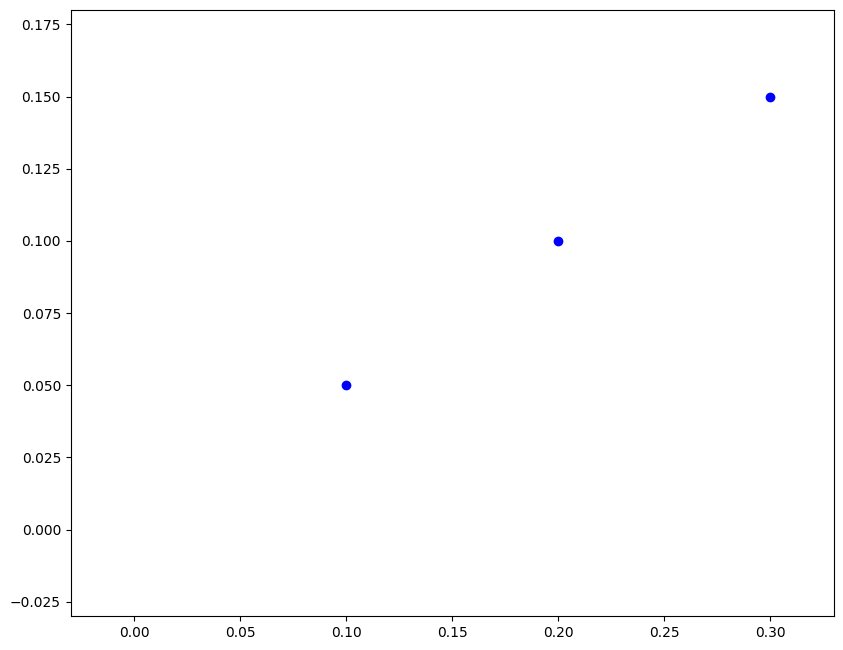

In [11]:
# On définit les caracteristiques des actifs risqués
d=3;rho=0.0;

min_esp=0.05;max_esp=0.15;
mu=np.linspace(min_esp,max_esp,d);

# On suppose que tous les actifs risqués ont une 
# corrélation constante égale à |$\rho$|.
# On doit forcement avoir |$\rho >= -(1/(d-1))$|, 
# sinon la matrice n'est pas une matrice de covariance (exercice!).
covariance=rho*np.ones([d,d])+(1-rho)*np.eye(d);

# On choisit un ecart type croissant en fonction de l'actif
min_sigma=0.1;max_sigma=0.3;
sigma=np.linspace(min_sigma,max_sigma,d);

# La matrice de variance covariance se calcule par :
Gamma = np.diag(sigma) * covariance * np.diag(sigma);

# Les caractéristiques des actifs de base
moyenne_actif=mu;
std_actif=np.sqrt(np.diag(Gamma));

# plot ###################################################################

# Tracé des actifs dans le plan (ecart-type,moyenne)
max_sigma=max(std_actif)
max_esp=max(moyenne_actif)
marge=0.03
un_inche_en_cm=2.54; # 1 inche = 2.54 cm

taille_h_cm=25;
taille_v_cm=20;

def plot1():
    # On crée un figure dont on fixe la taille et dont on définit les axes
    fig = plt.gcf();
    fig.set_size_inches(taille_h_cm/un_inche_en_cm,taille_v_cm/un_inche_en_cm);
    plt.axis([-marge, max_sigma+marge, -marge, max_esp+marge]);
    # On trace les points représentant les actifs de risqués
    plt.plot(sigma,mu, 'bo');

plot1();


#####  Etape 2. Tirages des portefeuilles à coefficients positifs.

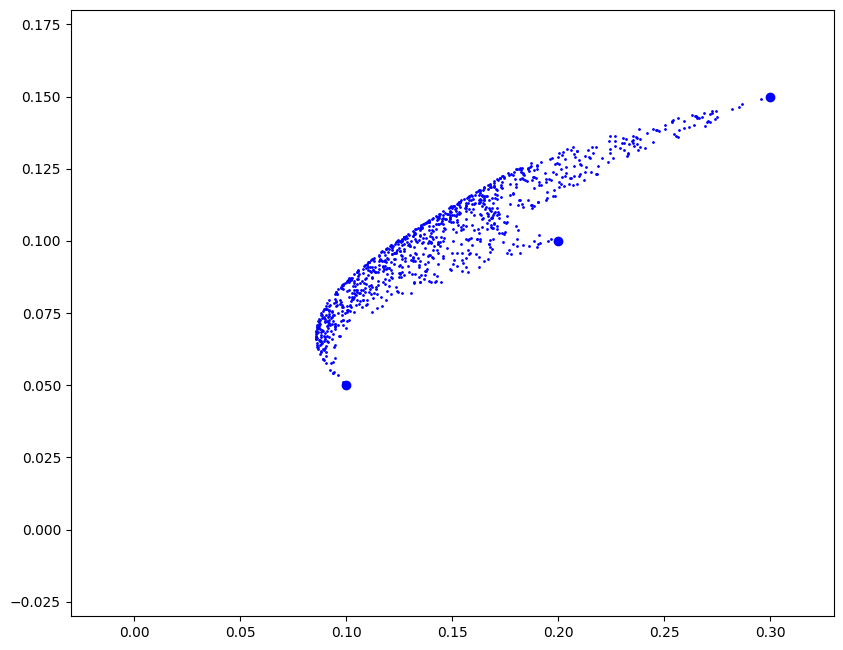

In [12]:
# On considère des portefeuilles *avec l'actif sans risque*
# mais *sans emprunt*. On les tire au hasard dans le simplexe
# de dimension 3
N=1000;
moyenne_x=np.zeros(N);
std_x=np.zeros(N);
for i in range(0,N):
  x=simplexe(d);# tirage au hasard dans le simplexe
  moyenne_x[i] = np.dot(mu,x);
  std_x[i]=math.sqrt(np.dot(x,np.matmul(Gamma,x)));

# plot ###################################################################
def plot2():
    plot1();# le plot précédent
    plt.plot(std_x, moyenne_x,'b.',markersize=2);

plot2();

#### Etape 3. Le point de variance minimum.

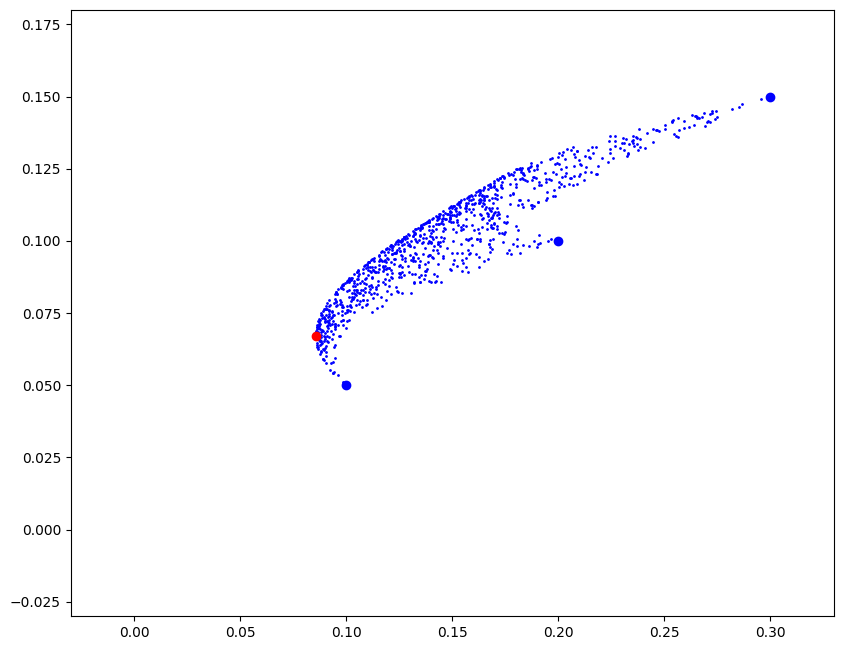

In [13]:
# Le point de variance minimum

# plot ###################################################################
def plot3():
    plot2();# le plot précédent
    imin=std_x.argmin();
    plt.plot(std_x[imin],moyenne_x[imin], 'ro',markersize=6);

plot3();

####  Etape 4. On autorise l'emprunt de l'actif 1

In [14]:
def arbitraire(d,sigma): 
# tirages de valeurs de signe arbitraire
# dont la somme vaut 1
#  -> l'emprunt est autorisé 
   t=np.random.normal(0,sigma,d-1);
   n=np.random.randint(d-1);
   s=np.zeros(d);
   s[0:n]=t[0:n];
   s[n]=1-np.sum(t);
   s[n+1:d]=t[n:d-1];
   return s;
  

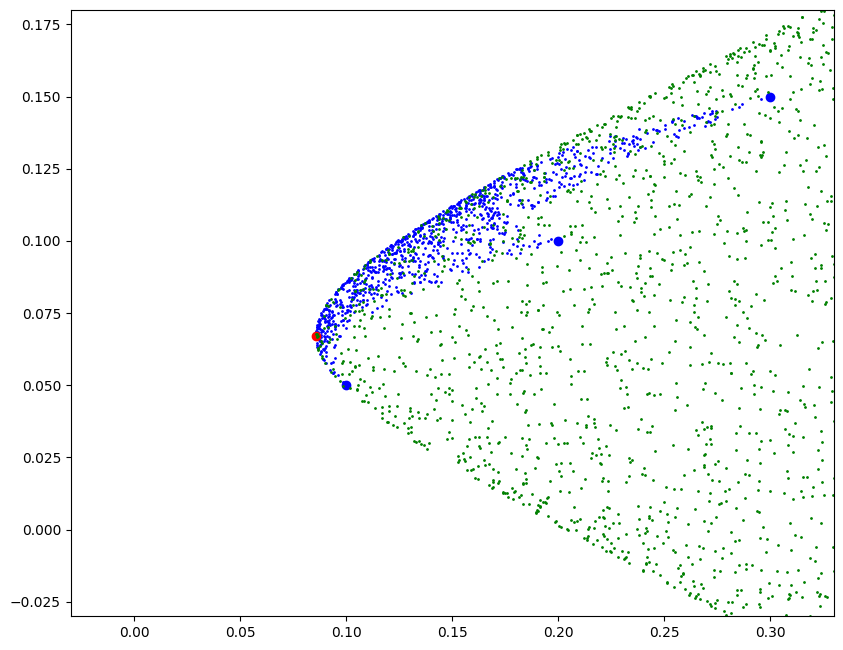

In [15]:
N=10000;
moyenne_x_1=np.zeros(N);
std_x_1=np.zeros(N);
sigma_e=2;
for i in range(0,N):
  x=arbitraire(d,sigma_e);
  moyenne_x_1[i] = np.dot(mu,x);
  std_x_1[i]=math.sqrt(np.dot(x,np.matmul(Gamma,x)));

# plot ###################################################################
def plot4():
    plot3();# le plot précédent
    plt.plot(std_x_1, moyenne_x_1,'g.',markersize=2);

plot4();

#### Etape 5. On rajoute un actif sans risque de moyenne nulle.

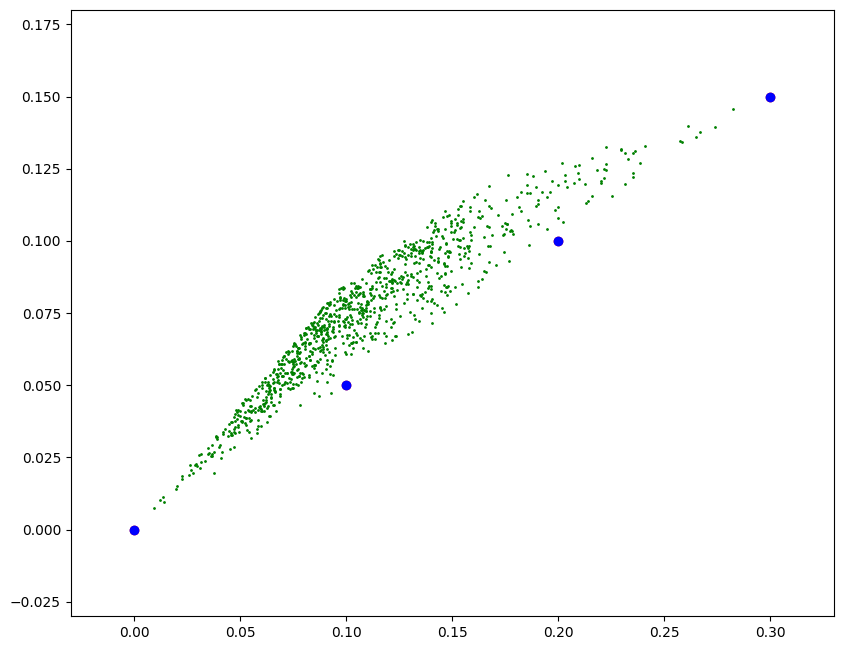

In [16]:

# On rajoute un actif sans risque de moyenne nulle
r0=0;
mu_d=np.append(r0,mu);
sigma_d=np.append(0,sigma);

rho=0.0;# -0.5
covariance=rho*np.ones([d,d])+(1-rho)*np.eye(d)
Gamma = np.matmul(np.matmul(np.diag(sigma),covariance), np.diag(sigma))

# comme ce rendement est suppose deterministe, la matrice de  
# variance covariance se complete par une ligne et une colonne de 0
Gamma_d=np.vstack([np.zeros(d),Gamma])
Gamma_d=np.c_[np.zeros(d+1),Gamma_d]

moyenne_actif=mu_d;
std_actif=np.sqrt(np.diag(Gamma_d));

# On materialise les 3+1 actifs de base
plt.plot(std_actif, moyenne_actif, 'ro');

# On considère des portefeuilles *avec l'actif sans risque*
# mais *sans emprunt*. On les tire au hasard dans le simplexe
# de dimension 3+1
N=1000;
moyenne_d_x=np.zeros(N);
std_d_x=np.zeros(N);
for i in range(0,N):
  x=simplexe(d+1);# tirage au hasard dans le simplexe
  moyenne_d_x[i] = np.dot(mu_d,x);
  std_d_x[i]=math.sqrt(np.dot(x,np.matmul(Gamma_d,x)));

# plot ###################################################################
def plot6():    
    fig = plt.gcf();
    fig.set_size_inches(taille_h_cm/un_inche_en_cm,taille_v_cm/un_inche_en_cm);
    plt.axis([-marge, max_sigma+marge, -marge, max_esp+marge]);

    # On materialise les 4 actifs de base
    plt.plot(std_actif, moyenne_actif, 'bo');

    # et les portefeuilles tirés au hasard
    plt.plot(std_d_x, moyenne_d_x,'g.',markersize=2);

plot6();


#### Etape 6. Identification du portefeuille de marché et de la droite de marché.

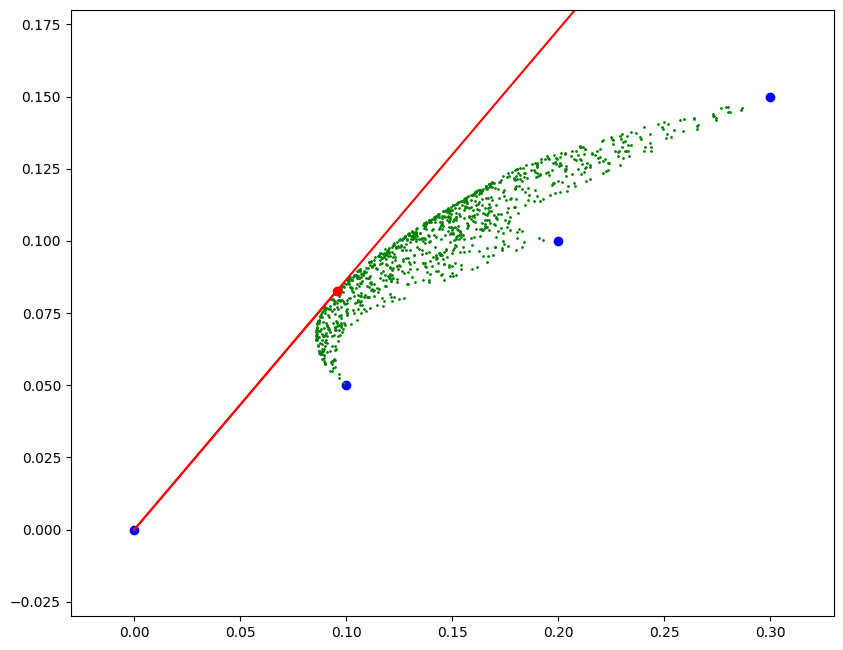

In [17]:
# r0=mu_d[0];
sigma0=math.sqrt(Gamma_d[0,0]);# sigma0 = Gamma(0,0) = 0
pente=0;
max_pente=0;

N=1000;
moyenne_d_x=np.zeros(N);
std_d_x=np.zeros(N);
for i in range(0,N):
  x=np.append(0,simplexe(d));# tirage au hasard dans le simplexe de dimension d, n rajoute 0
  moyenne_d_x[i] = np.dot(mu_d,x);
  std_d_x[i]=math.sqrt(np.dot(x,np.matmul(Gamma_d,x)));
  pente=(moyenne_d_x[i] - r0) / (std_d_x[i] - sigma0);# calcul de la pente
  max_pente=max(pente,max_pente);
  if max_pente==pente:
        imax=i

# Le point P maximise la pente de la droite entre (sigma0=0, x_0=r0) 
# et les portefeuilles y (sans actif sans risque)
x_P=moyenne_d_x[imax];
sigma_P=std_d_x[imax];

# plot ###################################################################
def plot7():
    plot6();# le plot précédent

    # Tracé du point P
    plt.plot(sigma_P, x_P, 'ro')

    # Tracé du segment "Actif sans risque -> P"
    plt.plot(np.array([sigma0,sigma_P]),np.array([r0,x_P]), 'r-');

    # Tracé de la droite "actif sans risque -> P" au dela de P
    lambd=(x_P-r0)/(sigma_P-sigma0)# pente de la droite
    sigma_infinity=2.0# arbitraire mais "grand"
    x_infinity=r0+lambd*(sigma_infinity-sigma0);
    plt.plot(np.array([sigma0,sigma_infinity]),np.array([r0,x_infinity]), 'r-');

plot7();

#### Etape 7. Simulation de portefeuilles avec emprunt de cash autorisé

Avec actif sans risque et emprunt autorisé. On tire au hasard
  sans imposer le signe de l'actif sans risque mais en gardant 
  la quantité de tous les actifs risqués positif. C'est fait par 
  la primitive arbitraire(d,sigma_e) qui fait un choix
  (arbitraire) pour la loi de la quantité d'actif sans risque.

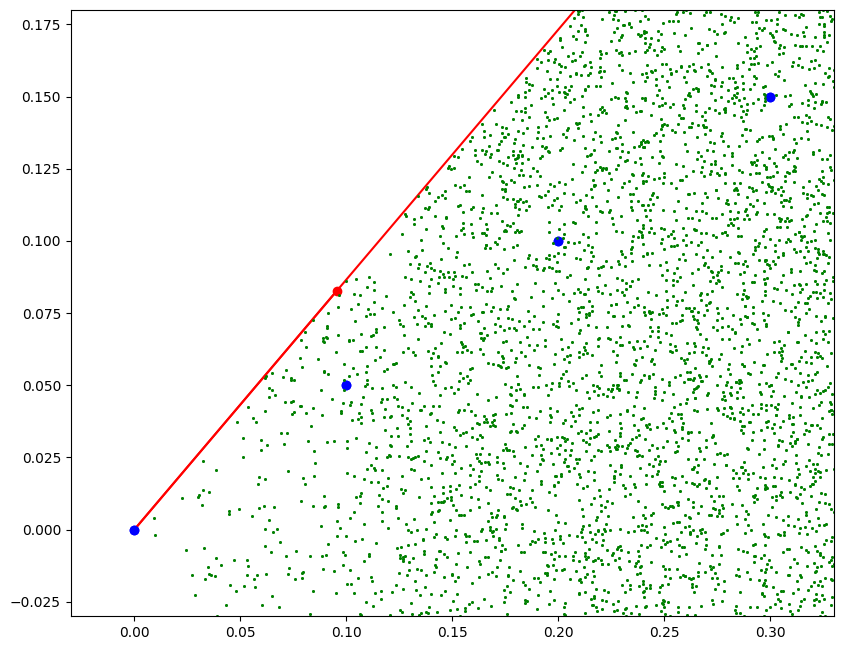

In [18]:
N=50000;
sigma_e=2.0;
moyenne_d_x=np.zeros(N);
std_d_x=np.zeros(N);
for i in range(0,N):
  x=arbitraire(d+1,sigma_e);# tirage au hasard dans le simplexe
  moyenne_d_x[i] = np.dot(mu_d,x);
  std_d_x[i]=math.sqrt(np.dot(x,np.matmul(Gamma_d,x)));

# plot ###################################################################
def plot8():    
    plot7();
    
    fig = plt.gcf();
    fig.set_size_inches(taille_h_cm/un_inche_en_cm,taille_v_cm/un_inche_en_cm);
    plt.axis([-marge, max_sigma+marge, -marge, max_esp+marge]);

    # On materialise les 4 actifs de base
    plt.plot(std_actif, moyenne_actif, 'bo');

    # et les portefeuilles tirés au hasard
    plt.plot(std_d_x, moyenne_d_x,'g.',markersize=2);

plot8();


On peut vérifier que tous les portefeuilles restent en dessous de la droite de marché.

Ce programme est paramétrable pour des valeurs de $d$ et $\rho$
arbitraires, si vous souhaitez expérimenter par vous même. Toutefois
des problèmes d'échantillonage se pose lorsque $d$ devient grand (au
delà de $5$, la loi uniforme sur le simplexe  "a du mal à visiter les
coins du simplexe", c'est une réalité géométrique incontournable).